# ПРАКТИЧЕСКАЯ РАБОТА №2
## Обработка изображений: фильтрация и морфология

---

### ЗАДАНИЕ 1. УДАЛЕНИЕ ШУМА
**Исходные данные**:
Возьмите любое изображение размером 800×600 пикселей. Сделайте 2 копии.
- 1.1. На первую копию наложите Гауссовский шум (зернистость).
- 1.2. На вторую копию наложите импульсный шум («соль и перец»).
- 1.3. К изображению с Гауссовским шумом примените размытие по Гауссу (kernel 5×5).
- 1.4. К изображению с «солью и перцем» примените медианный фильтр (окно 5×5).
- 1.5. Поменяйте фильтры местами:
  - К Гауссовскому шуму примените медиану
  - К «соли и перцу» примените размытие по Гауссу


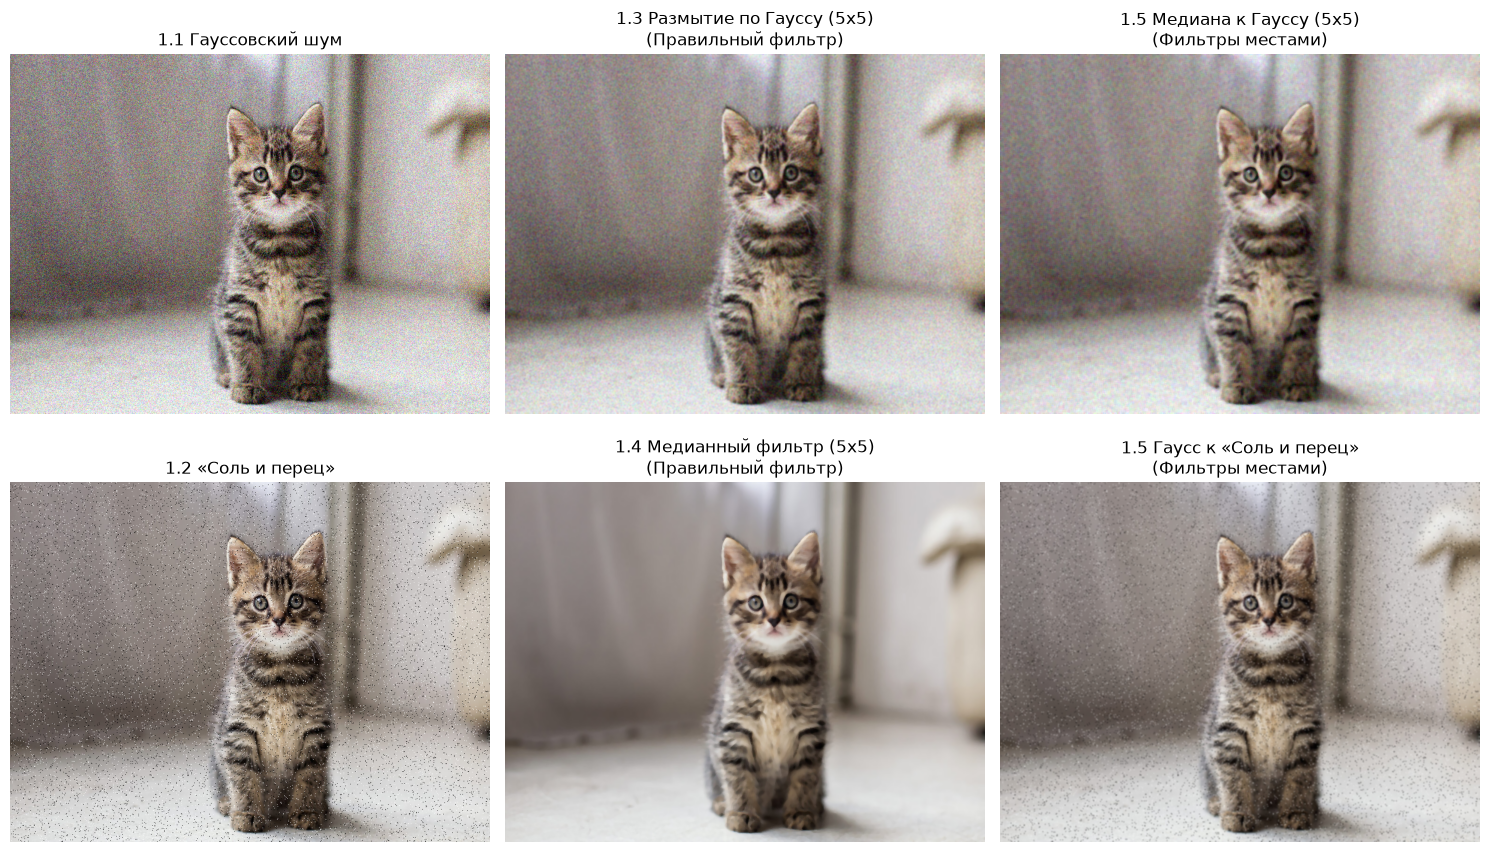

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()
    num_salt = int(np.ceil(amount * image.size * 0.5 / (image.shape[2] if len(image.shape) == 3 else 1)))
    coords = [np.random.randint(0, i, num_salt) for i in image.shape[:2]]
    noisy[coords[0], coords[1]] = 255

    num_pepper = int(np.ceil(amount * image.size * 0.5 / (image.shape[2] if len(image.shape) == 3 else 1)))
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape[:2]]
    noisy[coords[0], coords[1]] = 0
    return noisy

# Загрузка и подготовка изображения 800х600
original_bgr = cv2.imread('photo.jpg')
if original_bgr is None:
    original_bgr = np.zeros((600, 800, 3), dtype=np.uint8)
    cv2.circle(original_bgr, (400, 300), 150, (0, 200, 255), -1)
    cv2.putText(original_bgr, "CV LAB 2", (220, 320), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 4)
else:
    original_bgr = cv2.resize(original_bgr, (800, 600))

base = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
copy1 = base.copy()
copy2 = base.copy()

# 1.1 Гауссовский шум
gauss_noise = add_gaussian_noise(copy1, sigma=30)

# 1.2 Шум «соль и перец»
sp_noise = add_salt_pepper_noise(copy2, amount=0.04)

# 1.3 Гауссово размытие (5x5) к гауссовскому шуму
gauss_blur = cv2.GaussianBlur(gauss_noise, (5, 5), 0)

# 1.4 Медианный фильтр (5x5) к «соли и перцу»
median_sp = cv2.medianBlur(sp_noise, 5)

# 1.5 Меняем фильтры местами
median_on_gauss = cv2.medianBlur(gauss_noise, 5)
gauss_on_sp = cv2.GaussianBlur(sp_noise, (5, 5), 0)

# Визуализация
plt.figure(figsize=(15, 9))
plt.subplot(2, 3, 1)
plt.imshow(gauss_noise)
plt.title("1.1 Гауссовский шум")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gauss_blur)
plt.title("1.3 Размытие по Гауссу (5x5)\n(Правильный фильтр)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(median_on_gauss)
plt.title("1.5 Медиана к Гауссу (5x5)\n(Фильтры местами)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sp_noise)
plt.title("1.2 «Соль и перец»")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(median_sp)
plt.title("1.4 Медианный фильтр (5x5)\n(Правильный фильтр)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gauss_on_sp)
plt.title("1.5 Гаусс к «Соль и перец»\n(Фильтры местами)")
plt.axis("off")

plt.tight_layout()
plt.show()


#### Вопросы для вывода (Задание 1):
1. **Какой фильтр лучше убрал Гауссовский шум?**
   - **Ответ:** **Размытие по Гауссу (`cv2.GaussianBlur`)**. Гауссовский фильтр взвешенно усредняет значения в окрестности согласно нормальному распределению, что математически оптимально для подавления непрерывного аддитивного шума Гаусса.
2. **Какой фильтр лучше убрал «соль и перец»?**
   - **Ответ:** **Медианный фильтр (`cv2.medianBlur`)**. Импульсный шум проявляется в виде экстремальных выбросов (0 или 255). Медиана отбрасывает крайние выбросы и берет срединное значение окрестности, полностью вырезая «битые» пиксели без размытия контуров.
3. **Почему при замене фильтров результат стал хуже?**
   - **Ответ:** 
     - При применении *размытия по Гауссу* к «соли и перцу» экстремальные черные/белые пиксели не удаляются, а усредняются с соседними точками, превращаясь в размытые серые пятна (грязь).
     - При применении *медианы* к гауссовскому шуму картинка приобретает эффект пластилиновости/акварели, так как непрерывный шум присутствует везде, и медиана искажает гладкие переходы яркости.


---
### ЗАДАНИЕ 2. ПОВЫШЕНИЕ РЕЗКОСТИ
**Исходные данные**:
Используйте изображение из Задания 1 после применения правильного фильтра (чистое изображение).
- 2.1. Примените повышение резкости к чистому изображению.
- 2.2. К изображению с шумом (до фильтрации) примените повышение резкости.
- 2.3. Примените цепочку: Шумное изображение → Медианный фильтр → Повышение резкости
- 2.4. Примените цепочку: Шумное изображение → Повышение резкости → Медианный фильтр


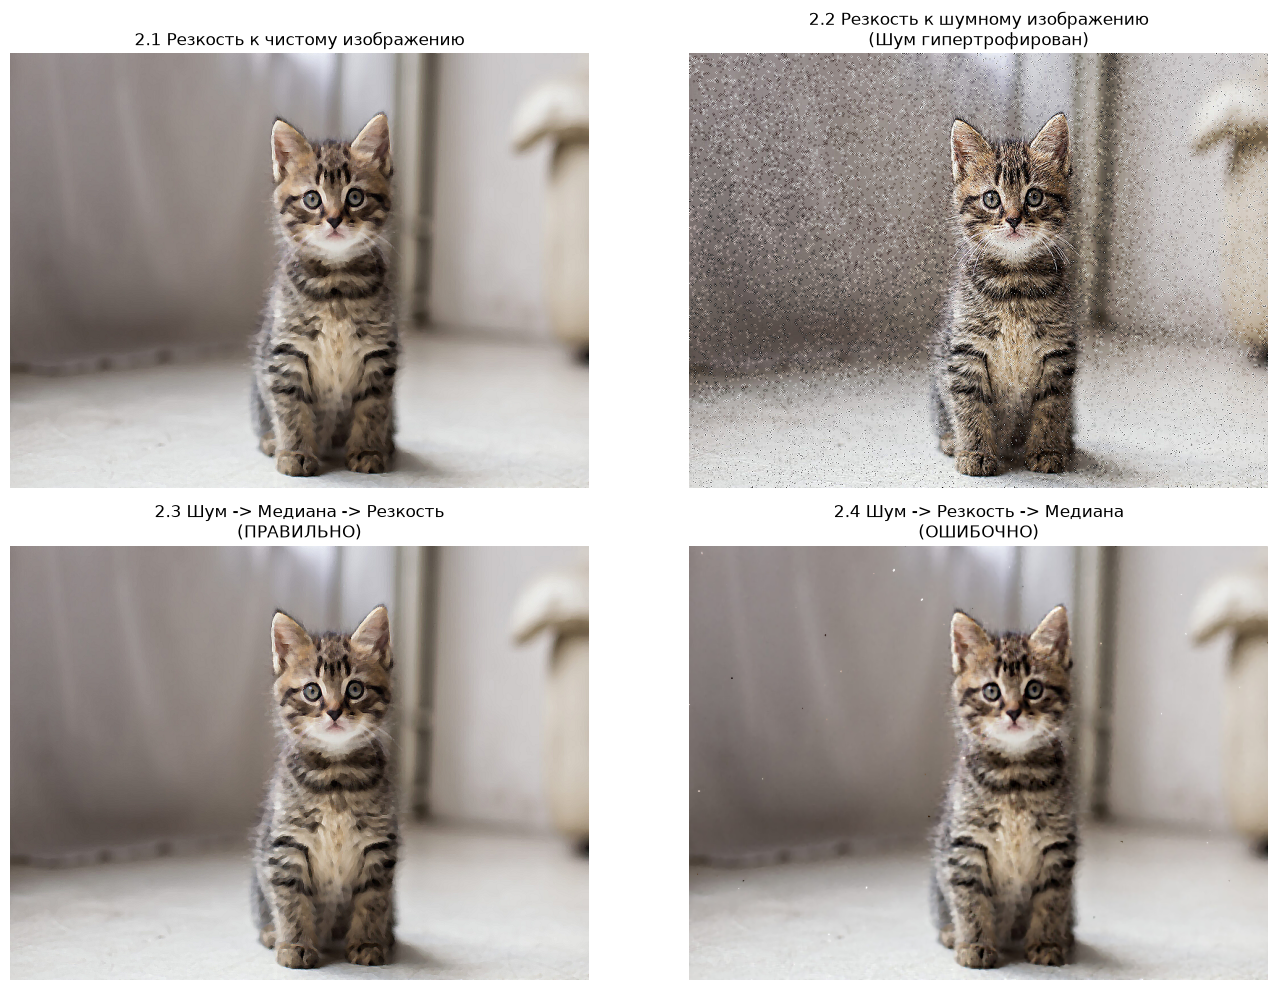

In [12]:
# Чистое изображение после правильной фильтрации
clean = median_sp.copy()

# Ядро повышения резкости
kernel_sharp = np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]], dtype=np.float32)

def sharpen(img):
    return cv2.filter2D(img, -1, kernel_sharp)

# 2.1 К чистому изображению
sharp_clean = sharpen(clean)

# 2.2 К шумному изображению (до фильтрации)
sharp_noisy = sharpen(sp_noise)

# 2.3 Цепочка: Шум -> Медиана -> Резкость
chain_med_sharp = sharpen(cv2.medianBlur(sp_noise, 5))

# 2.4 Цепочка: Шум -> Резкость -> Медиана
chain_sharp_med = cv2.medianBlur(sharpen(sp_noise), 5)

# Визуализация
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.imshow(sharp_clean)
plt.title("2.1 Резкость к чистому изображению")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sharp_noisy)
plt.title("2.2 Резкость к шумному изображению\n(Шум гипертрофирован)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(chain_med_sharp)
plt.title("2.3 Шум -> Медиана -> Резкость\n(ПРАВИЛЬНО)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(chain_sharp_med)
plt.title("2.4 Шум -> Резкость -> Медиана\n(ОШИБОЧНО)")
plt.axis("off")

plt.tight_layout()
plt.show()


#### Вопросы для вывода (Задание 2):
1. **Что произошло с шумом после повышения резкости?**
   - **Ответ:** Шум многократно усилился и стал агрессивным. Фильтр резкости выделяет и усиливает высокочастотные перепады яркости (лапласиан). Поскольку шум — это высокочастотные скачки, резкость превратила каждую точку шума в крупный контрастный артефакт.
2. **Сравните результат пунктов 2.3 и 2.4. Какой лучше и почему?**
   - **Ответ:** **Результат пункта 2.3 значительно лучше**. 
     - В п. 2.3 медианный фильтр сначала чисто удаляет точки шума, а затем повышение резкости усиливает только полезные контуры объектов сцены.
     - В п. 2.4 резкость сначала усиливает шум и разносит его влияние на соседей (ядро 3×3), из-за чего последующий медианный фильтр уже не может устранить искажения и оставляет мутные артефакты.
3. **Сформулируйте правило: когда применять повышение резкости?**
   - **Ответ:** **Правило:** Повышение резкости следует применять **ТОЛЬКО ПОСЛЕ** подавления шума на предварительно отфильтрованном изображении. Никогда нельзя применять шарпинг к зашумленным данным.


---
### ЗАДАНИЕ 3. МОРФОЛОГИЯ (БАЗОВЫЕ ОПЕРАЦИИ)
**Исходные данные**:
Создайте черно-белое изображение размером 500×500 пикселей. Нарисуйте:
- Толстую букву «О» (толщина линии 20 пикселей)
- Одну белую точку за пределами буквы (мусор)
- Одну черную точку внутри буквы (дырка)

**Что сделать**:
- 3.1. Примените Эрозию (1 итерация). Запишите, что изменилось.
- 3.2. Примените Дилатацию (1 итерация) к исходному изображению. Запишите, что изменилось.
- 3.3. К исходному изображению примените цепочку: Эрозия → Дилатация (Открытие)
- 3.4. К исходному изображению примените цепочку: Дилатация → Эрозия (Закрытие)


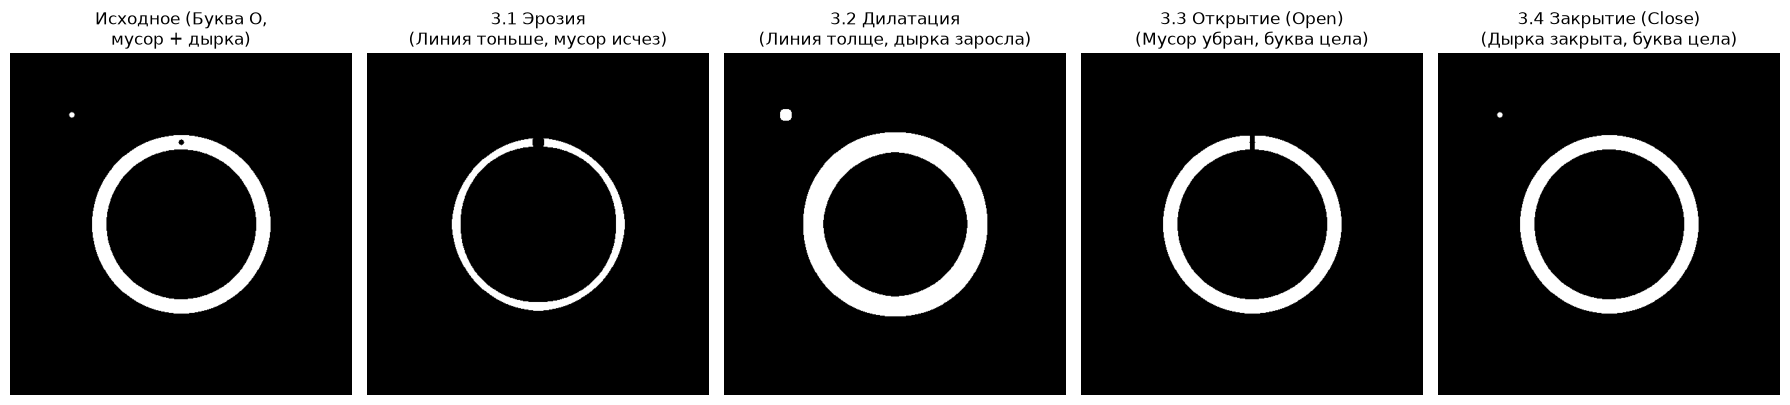

In [13]:
# Создаем черно-белое изображение 500x500
img_task3 = np.zeros((500, 500), dtype=np.uint8)

# Толстая буква «О» (толщина 20px)
cv2.circle(img_task3, (250, 250), 120, 255, thickness=20)

# Белая точка за пределами буквы (мусор)
cv2.circle(img_task3, (90, 90), 4, 255, thickness=-1)

# Черная точка внутри белой линии буквы (дырка)
cv2.circle(img_task3, (250, 130), 4, 0, thickness=-1)

# Ядро морфологии
kernel_morph = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

# 3.1 Эрозия (1 итерация)
erosion_3_1 = cv2.erode(img_task3, kernel_morph, iterations=1)

# 3.2 Дилатация (1 итерация к исходнику)
dilation_3_2 = cv2.dilate(img_task3, kernel_morph, iterations=1)

# 3.3 Открытие (Эрозия -> Дилатация)
opening_3_3 = cv2.morphologyEx(img_task3, cv2.MORPH_OPEN, kernel_morph)

# 3.4 Закрытие (Дилатация -> Эрозия)
closing_3_4 = cv2.morphologyEx(img_task3, cv2.MORPH_CLOSE, kernel_morph)

# Визуализация
plt.figure(figsize=(18, 5))
titles = [
    "Исходное (Буква О,\nмусор + дырка)",
    "3.1 Эрозия\n(Линия тоньше, мусор исчез)",
    "3.2 Дилатация\n(Линия толще, дырка заросла)",
    "3.3 Открытие (Open)\n(Мусор убран, буква цела)",
    "3.4 Закрытие (Close)\n(Дырка закрыта, буква цела)"
]
imgs = [img_task3, erosion_3_1, dilation_3_2, opening_3_3, closing_3_4]

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


#### Вопросы для вывода (Задание 3):
1. **Что произошло с буквой «О» после эрозии?**
   - **Ответ:** Толщина линии буквы уменьшилась (линия стала тоньше), внутреннее черное пространство буквы увеличилось, внешние границы сузились.
2. **Что произошло с дыркой после дилатации?**
   - **Ответ:** Дырка (черная точка внутри белой линии) полностью затянулась/исчезла, так как белая область расширилась во все стороны.
3. **Что случилось с мусором после открытия (Открытие = Эрозия → Дилатация)?**
   - **Ответ:** Белый мусор снаружи полностью исчез! На шаге эрозии маленькая точка была полностью стёрта, и последующая дилатация уже не смогла её восстановить, вернув исходную форму буквы «О».
4. **Что случилось с дыркой после закрытия (Закрытие = Дилатация → Эрозия)?**
   - **Ответ:** Черная дырка внутри буквы полностью затянулась! Дилатация расширила белый объект и закрасила пустоту, а последующая эрозия восстановила внешние контуры буквы до начальных размеров.


---
### ЗАДАНИЕ 4. ВОССТАНОВЛЕНИЕ ЛИНИЙ
**Исходные данные**:
Создайте черно-белое изображение 500×500 пикселей. Нарисуйте:
- Горизонтальную линию толщиной 10 пикселей
- Сделайте в линии РАЗРЫВ (промежуток 10 пикселей)
- Добавьте 5 мелких белых точек вокруг линии

**Что сделать**:
- 4.1. Примените Эрозию. Запишите, что стало с разрывом.
- 4.2. Примените Дилатацию к исходнику. Запишите, что стало с разрывом.
- 4.3. Примените Закрытие (Дилатация → Эрозия).
- 4.4. Примените Открытие (Эрозия → Дилатация) к другому исходнику.


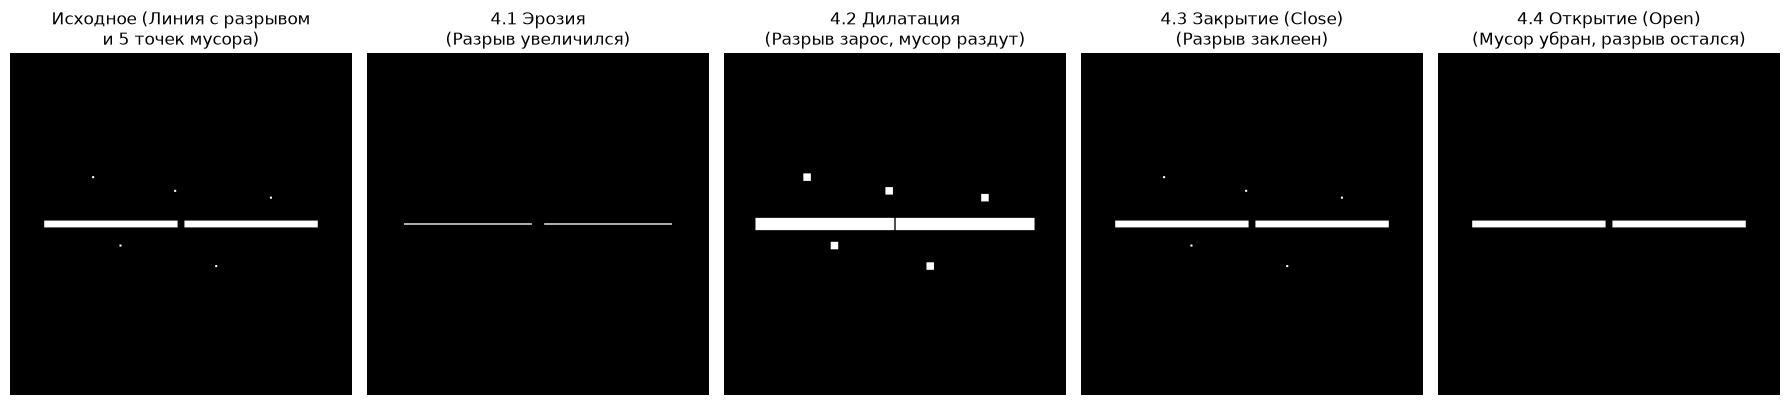

In [14]:
# Создаем черно-белое изображение 500х500
img_task4 = np.zeros((500, 500), dtype=np.uint8)

# Линия толщиной 10px
img_task4[245:255, 50:450] = 255

# Разрыв 10px в линии
img_task4[245:255, 245:255] = 0

# 5 мелких белых точек вокруг линии
noise_dots = [(180, 120), (210, 380), (280, 160), (310, 300), (200, 240)]
for y, x in noise_dots:
    img_task4[y:y+3, x:x+3] = 255

# Ядро для ликвидации разрыва 10px
kernel_line = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

# 4.1 Эрозия
erosion_4_1 = cv2.erode(img_task4, kernel_line, iterations=1)

# 4.2 Дилатация
dilation_4_2 = cv2.dilate(img_task4, kernel_line, iterations=1)

# 4.3 Закрытие
closing_4_3 = cv2.morphologyEx(img_task4, cv2.MORPH_CLOSE, kernel_line)

# 4.4 Открытие
opening_4_4 = cv2.morphologyEx(img_task4, cv2.MORPH_OPEN, kernel_line)

# Визуализация
plt.figure(figsize=(18, 5))
titles4 = [
    "Исходное (Линия с разрывом\nи 5 точек мусора)",
    "4.1 Эрозия\n(Разрыв увеличился)",
    "4.2 Дилатация\n(Разрыв зарос, мусор раздут)",
    "4.3 Закрытие (Close)\n(Разрыв заклеен)",
    "4.4 Открытие (Open)\n(Мусор убран, разрыв остался)"
]
imgs4 = [img_task4, erosion_4_1, dilation_4_2, closing_4_3, opening_4_4]

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(imgs4[i], cmap='gray')
    plt.title(titles4[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


#### Вопросы для вывода (Задание 4):
1. **Какая операция заклеила разрыв?**
   - **Ответ:** **Закрытие (Closing)** (а также промежуточная Дилатация). Закрытие соединяет соседние разрывы размером меньше ядра, сохраняя при этом исходную толщину линии.
2. **Какая операция убрала мусор?**
   - **Ответ:** **Открытие (Opening)** (а также промежуточная Эрозия). Открытие эффективно удаляет все мелкие изолированные белые точки мусора на фоне.
3. **Почему порядок операций важен?**
   - **Ответ:** Операции некоммутативны:
     - При *Закрытии* (Дилатация → Эрозия) первой работает дилатация: она сначала объединяет компоненты и склеивает разрыв.
     - При *Открытии* (Эрозия → Дилатация) первой работает эрозия: она сразу стирает объекты меньше ядра и расширяет имеющийся разрыв линии, препятствуя его восстановлению.


---
### ЗАДАНИЕ 5. ИТОГОВОЕ (САМОСТОЯТЕЛЬНОЕ)
**Исходные данные**:
Создайте черно-белое изображение с текстом или отпечатком пальца. На нем должны быть:
- Разрывы линий (2-3 разрыва)
- Мелкий мусор (5-10 точек)

**Что сделать**:
- 5.1. Примените последовательность: Закрытие → Открытие
- 5.2. Примените последовательность: Открытие → Закрытие
- 5.3. Сравните результаты.


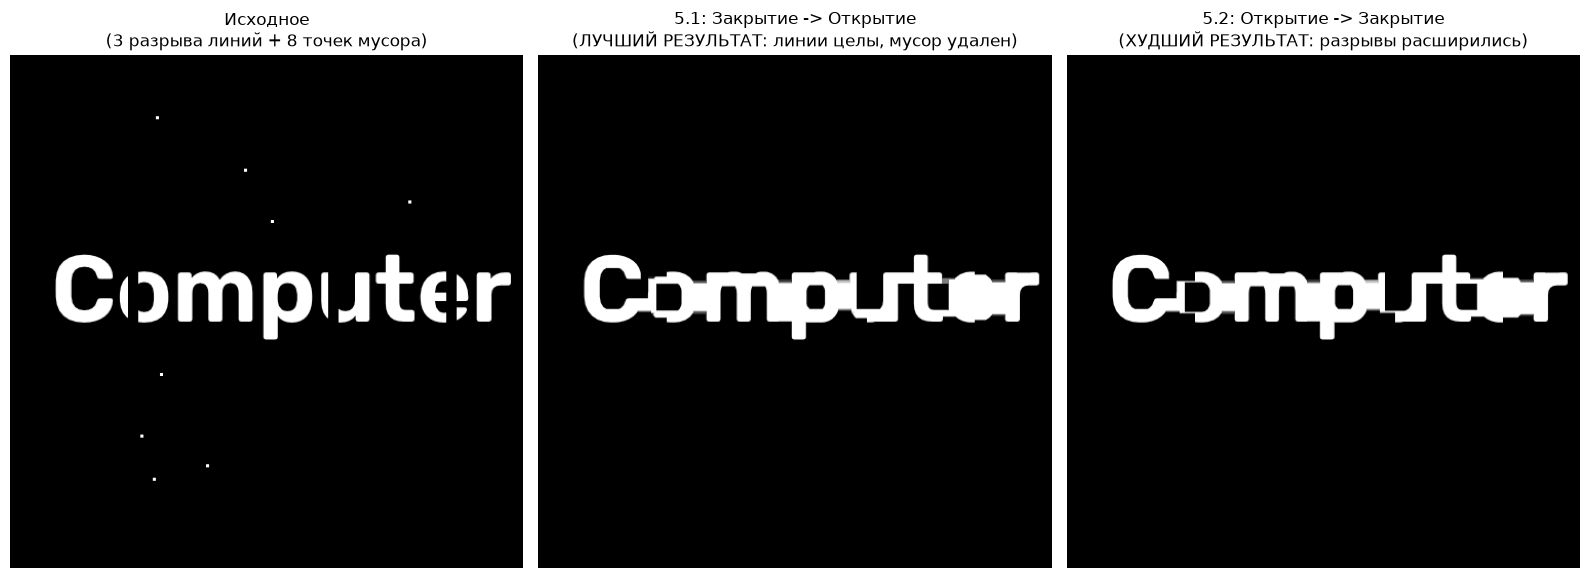

In [15]:
# Создаем изображение 500х500 с текстом
img_task5 = np.zeros((500, 500), dtype=np.uint8)
cv2.putText(img_task5, "Computer Vision", (40, 260), cv2.FONT_HERSHEY_SIMPLEX, 3.2, 255, thickness=12)

# Создаем 3 разрыва линий (шириной 10px)
img_task5[170:270, 115:125] = 0   # Разрыв в букве P
img_task5[170:270, 310:320] = 0   # Разрыв в букве C
img_task5[170:270, 425:435] = 0   # Разрыв в букве V

# Добавляем 8 мелких точек мусора
np.random.seed(42)
for _ in range(8):
    ry = np.random.randint(40, 460)
    rx = np.random.randint(40, 460)
    if img_task5[ry, rx] == 0:
        img_task5[ry:ry+3, rx:rx+3] = 255

# Ядра
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# 5.1 Последовательность: Закрытие -> Открытие
close_then_open = cv2.morphologyEx(img_task5, cv2.MORPH_CLOSE, kernel_close)
close_then_open = cv2.morphologyEx(close_then_open, cv2.MORPH_OPEN, kernel_open)

# 5.2 Последовательность: Открытие -> Закрытие
open_then_close = cv2.morphologyEx(img_task5, cv2.MORPH_OPEN, kernel_open)
open_then_close = cv2.morphologyEx(open_then_close, cv2.MORPH_CLOSE, kernel_close)

# 5.3 Визуализация и сравнение результатов
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_task5, cmap='gray')
plt.title("Исходное\n(3 разрыва линий + 8 точек мусора)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(close_then_open, cmap='gray')
plt.title("5.1: Закрытие -> Открытие\n(ЛУЧШИЙ РЕЗУЛЬТАТ: линии целы, мусор удален)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(open_then_close, cmap='gray')
plt.title("5.2: Открытие -> Закрытие\n(ХУДШИЙ РЕЗУЛЬТАТ: разрывы расширились)")
plt.axis("off")

plt.tight_layout()
plt.show()


#### Вопросы для вывода (Задание 5):
1. **Какая последовательность дала лучший результат?**
   - **Ответ:** **Последовательность 5.1 (Закрытие → Открытие)** показала наилучший результат. Она сначала надежно склеила разрывы в линиях текста, а затем аккуратно удалила изолированный фоновый мусор без повреждения геометрии букв.
2. **Почему нельзя менять порядок?**
   - **Ответ:** При изменении порядка (Открытие → Закрытие) этап Открытия начинает с эрозии. Эрозия не только удаляет мусор, но и «выедает» края разорванных линий, увеличивая зазоры в 1.5–2 раза. В итоге последующее Закрытие уже не может ликвидировать столь широкие разрывы (либо потребует гипертрофированного ядра, которое склеит между собой соседние буквы и превратит текст в сплошное белое пятно).
3. **Сформулируйте правило для восстановления линий с мусором:**
   - **Ответ:** **Правило:**
     1. Сначала применить операцию **Закрытия (Closing)** с ядром, достаточным для соединения разрывов ($size_{kernel} \ge gap_{width}$), пока края не разрушены.
     2. Затем применить операцию **Открытия (Opening)** с размером ядра, строго меньшим толщины линий ($size_{noise} \le size_{kernel} < line_{thickness}$), чтобы удалить изолированный мусор без повреждения восстановленных линий.
